In [92]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot

from lib_fitting import lin_fit
from lib_equations import trapezoidal, Simpson, loc_trapezoidal, loc_Simpson


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Test for the functions: $\int_{-1} ^1 e^x \approx 2.350402$**

In [93]:
# Params
a = -1
b = 1
dx_ = 1e-6

func = np.exp

res_t = trapezoidal(func, a, b, dx_)

# Results
print(f'a = {a}')
print(f'b = {b}\n')

print('I{a, b} =', res_t)

2000000
a = -1
b = 1

I{a, b} = 2.3504023872877986


In [94]:
res_s = Simpson(func, a, b, dx_)

print(f'a = {a}')
print(f'b = {b}\n')

print('I{a, b} =', res_s)

a = -1
b = 1

I{a, b} = 2.3504023872876023


In [95]:
diff = abs(res_t - res_s)
print('diff = ', diff)

diff =  1.9628743075372768e-13


# **Test for the scaling in $\int_{x_0} ^{x_0 + \delta x} \sin^2 \frac{x}{2} dx $**

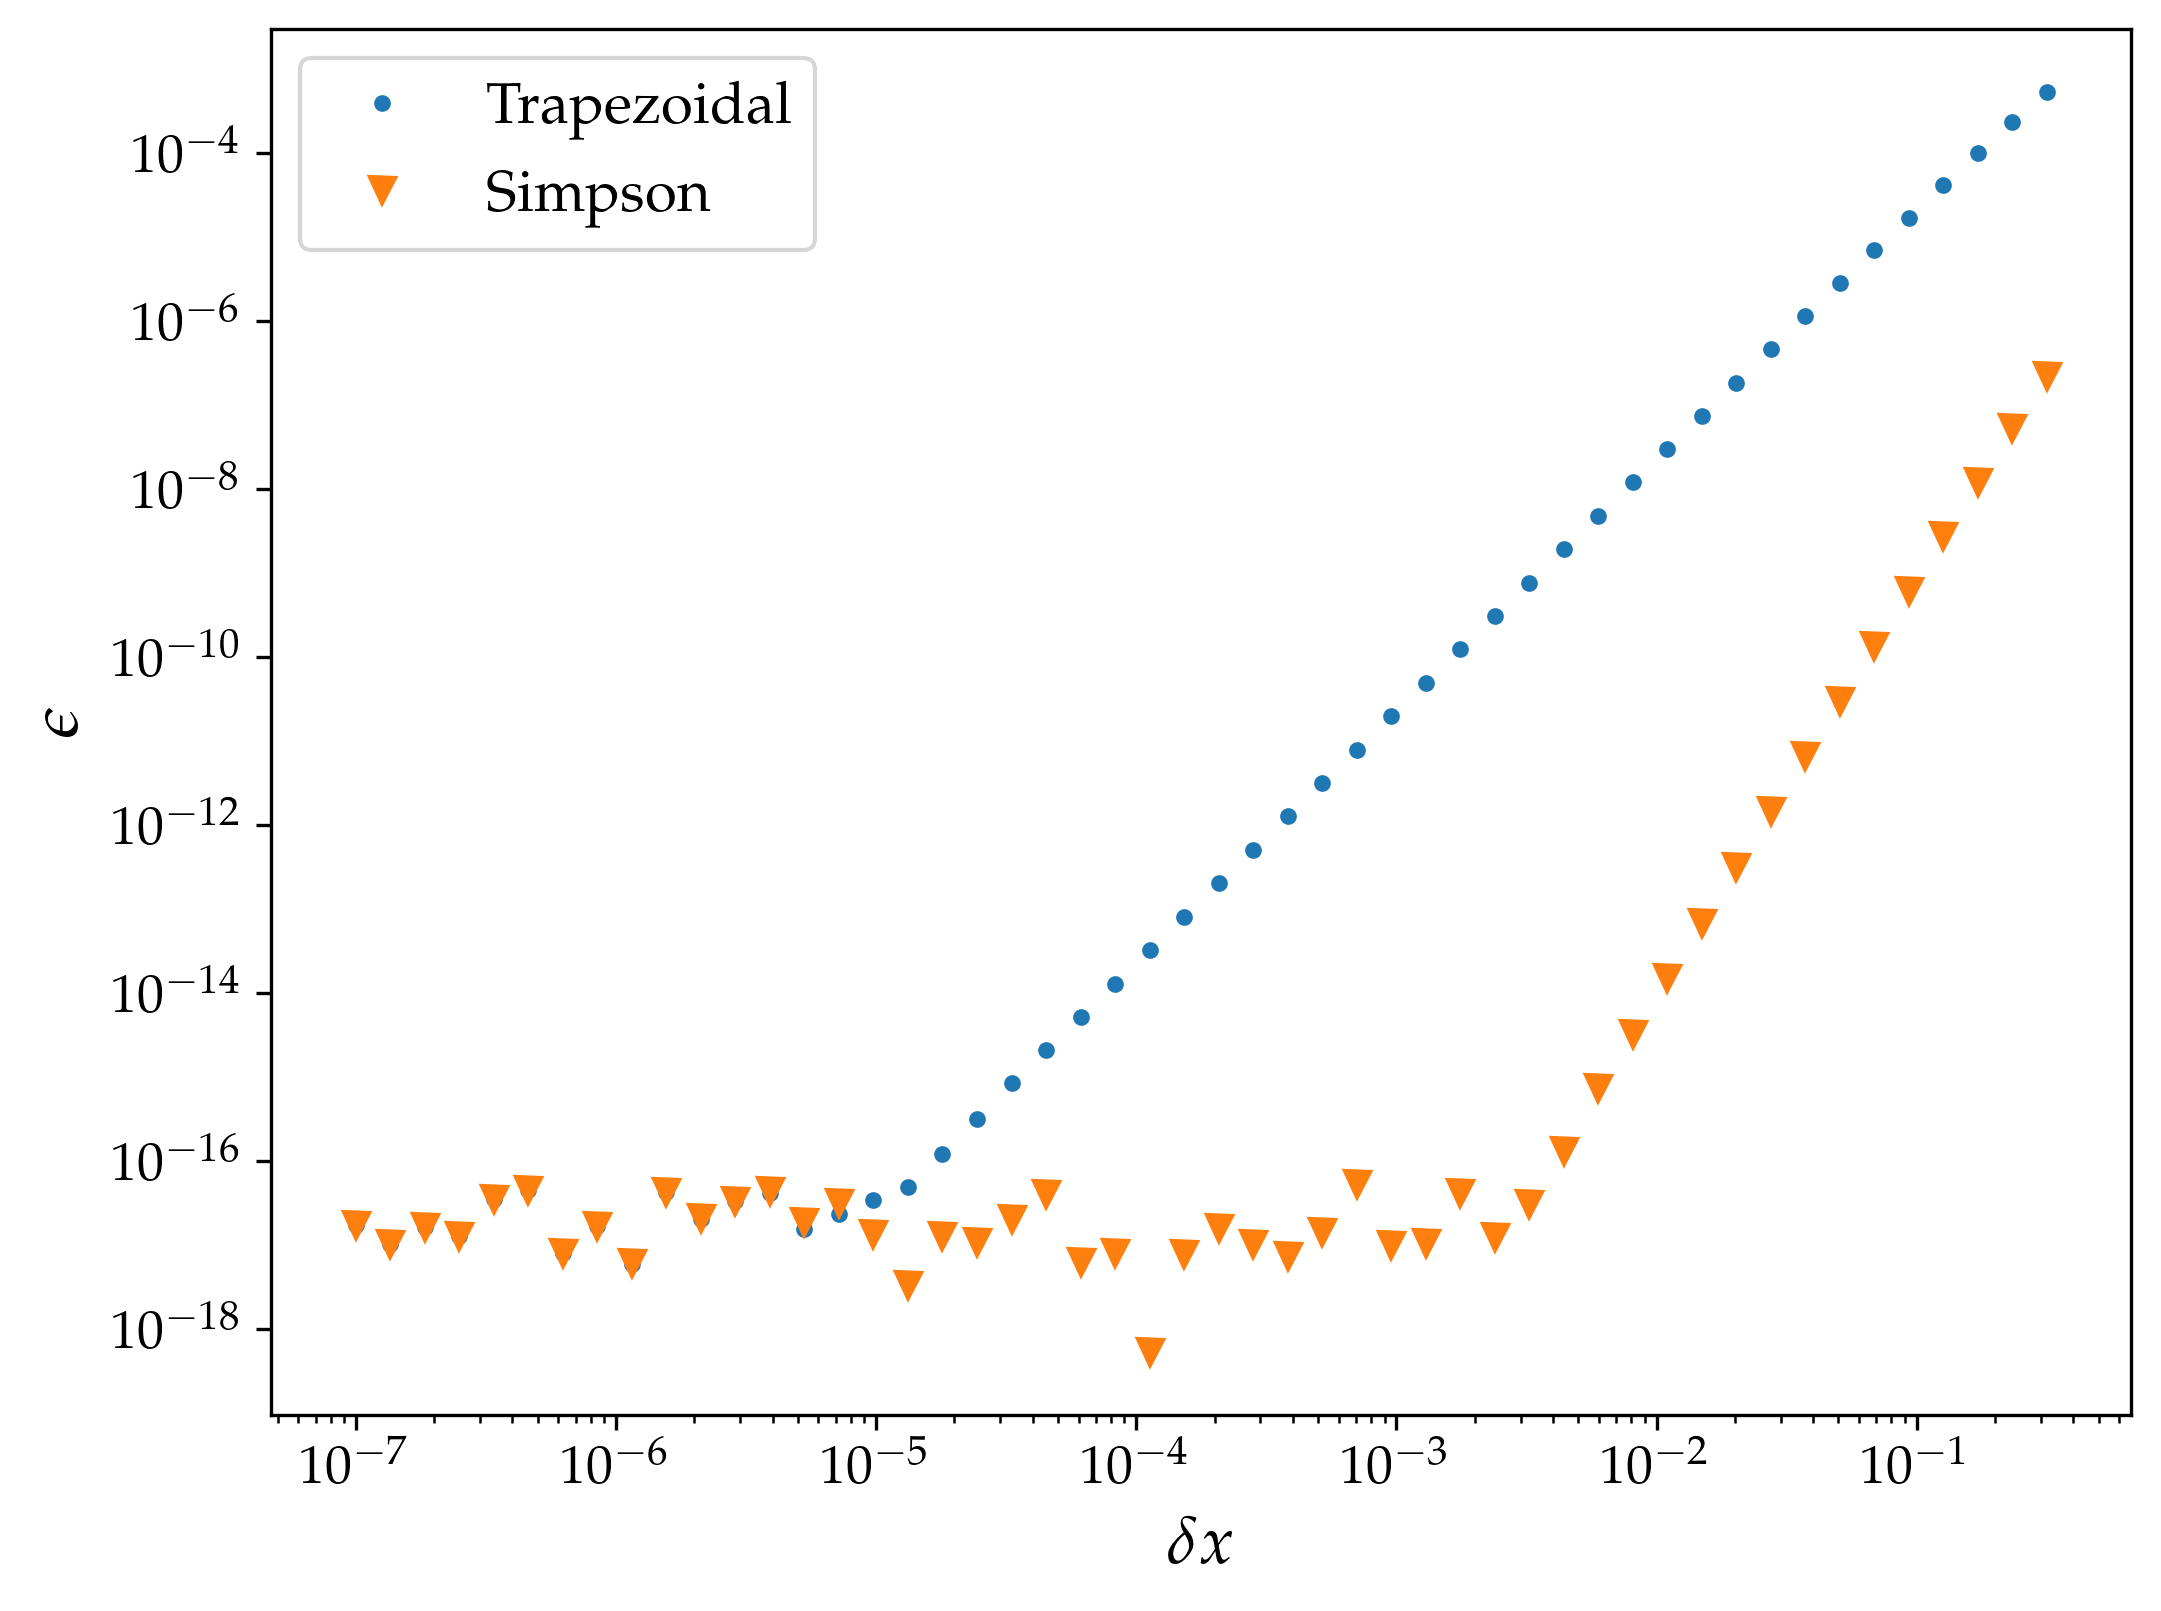

In [96]:
func = lambda x: np.sin(x/2)**2
sols = lambda x: (x - np.sin(x))/2
x_0 = 1.

dx_arr = np.logspace(-7, -0.5, 50)
error = [[], []]
for dx_ in dx_arr:
    for i in range(2):
        gr_spec = [['Trapezoidal', '.', loc_trapezoidal], 
                ['Simpson', 'v', loc_Simpson ]]
        
        true = sols(x_0+dx_) - sols(x_0)
        f_int = gr_spec[i][2]
        
        err = np.abs(f_int(func, x_0, dx=dx_) - true)
        error[i].append(err)

for i in range(2):
    plt.loglog(dx_arr, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.show()


## **Check slope of *Trapezoid***

<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
C:\Users\Marco\AppData\Local\Temp\ipykernel_18736\3851246033.py:7: SyntaxWarning: invalid escape sequence '\F'
  labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots\Fit_LocTrap')


dof = 28

a = 2.98e+00 +/- 1.590e-01
b = -1.71e+00 +/- 4.264e-01

Chi2 = 0.01
p-val = 1.00


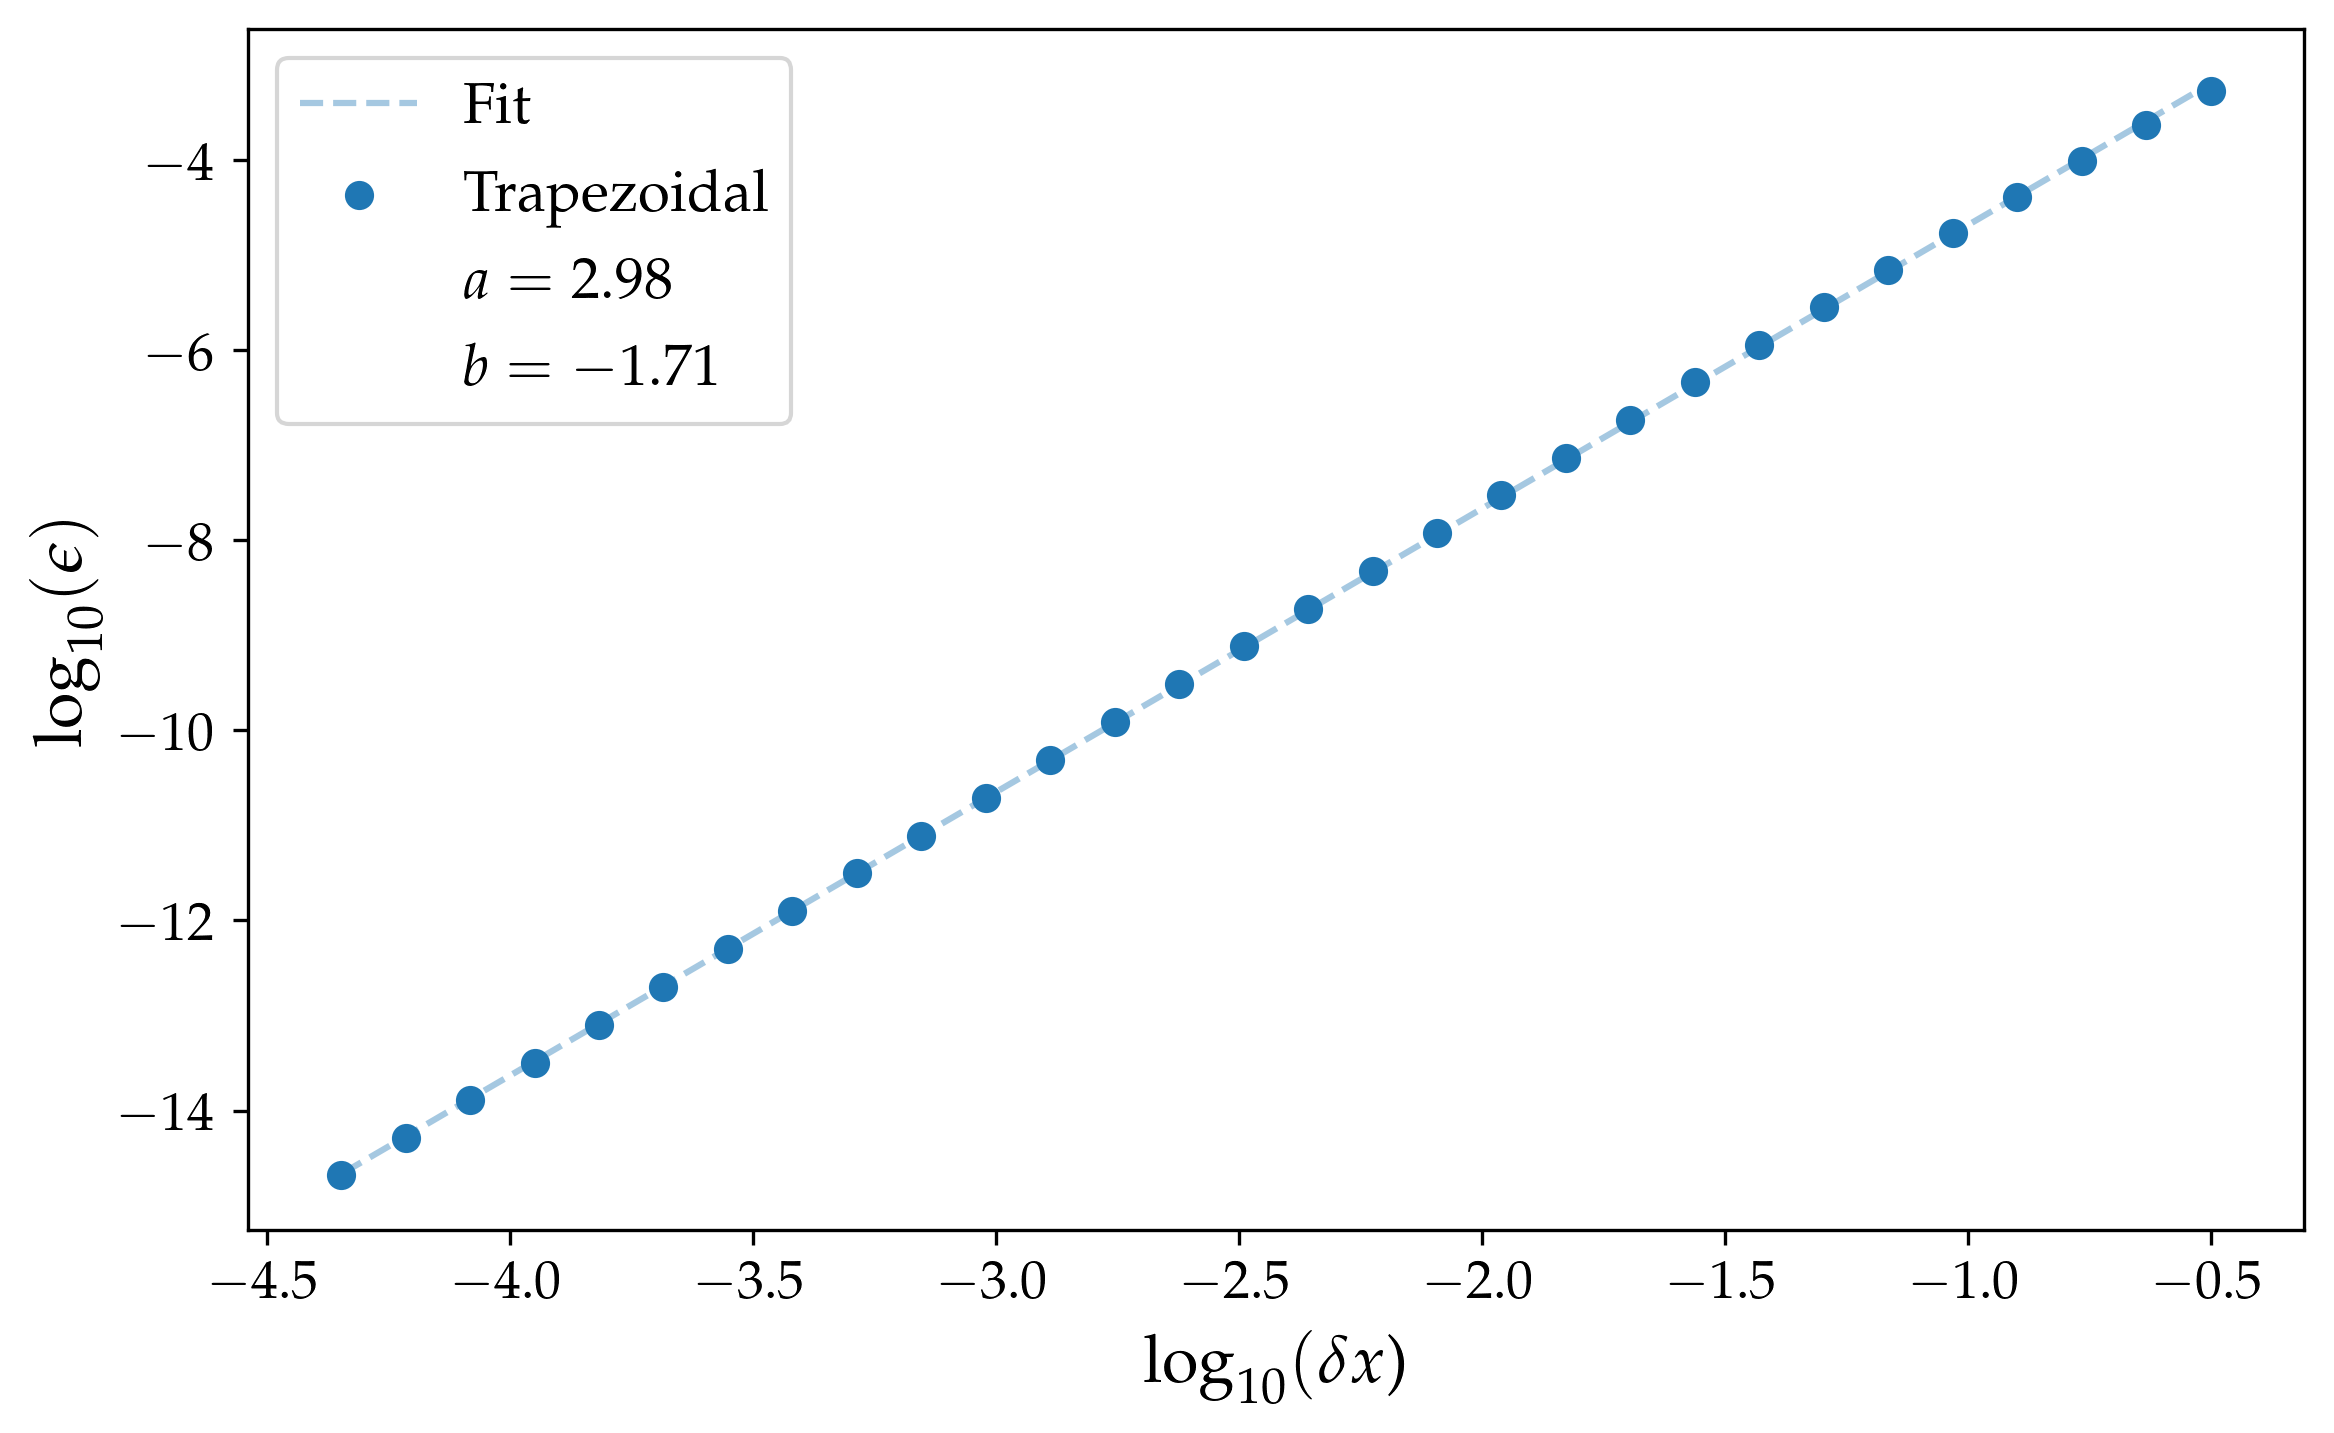

([np.float64(2.981410021822419), np.float64(-1.7075174067648329)],
 array([[0.02528516, 0.06127782],
        [0.06127782, 0.18183825]]),
 np.float64(0.013693643678503509),
 np.float64(1.0))

In [97]:
i = 0 
cut = 20
dx, eps_dx = (dx_arr[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots\Fit_LocTrap')

## **Check slope of *Simpson***

<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
C:\Users\Marco\AppData\Local\Temp\ipykernel_18736\1057322359.py:7: SyntaxWarning: invalid escape sequence '\F'
  labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots\Fit_LocSimp')


dof = 13

a = 4.96e+00 +/- 4.505e-01
b = -4.12e+00 +/- 6.934e-01

Chi2 = 0.01
p-val = 1.00


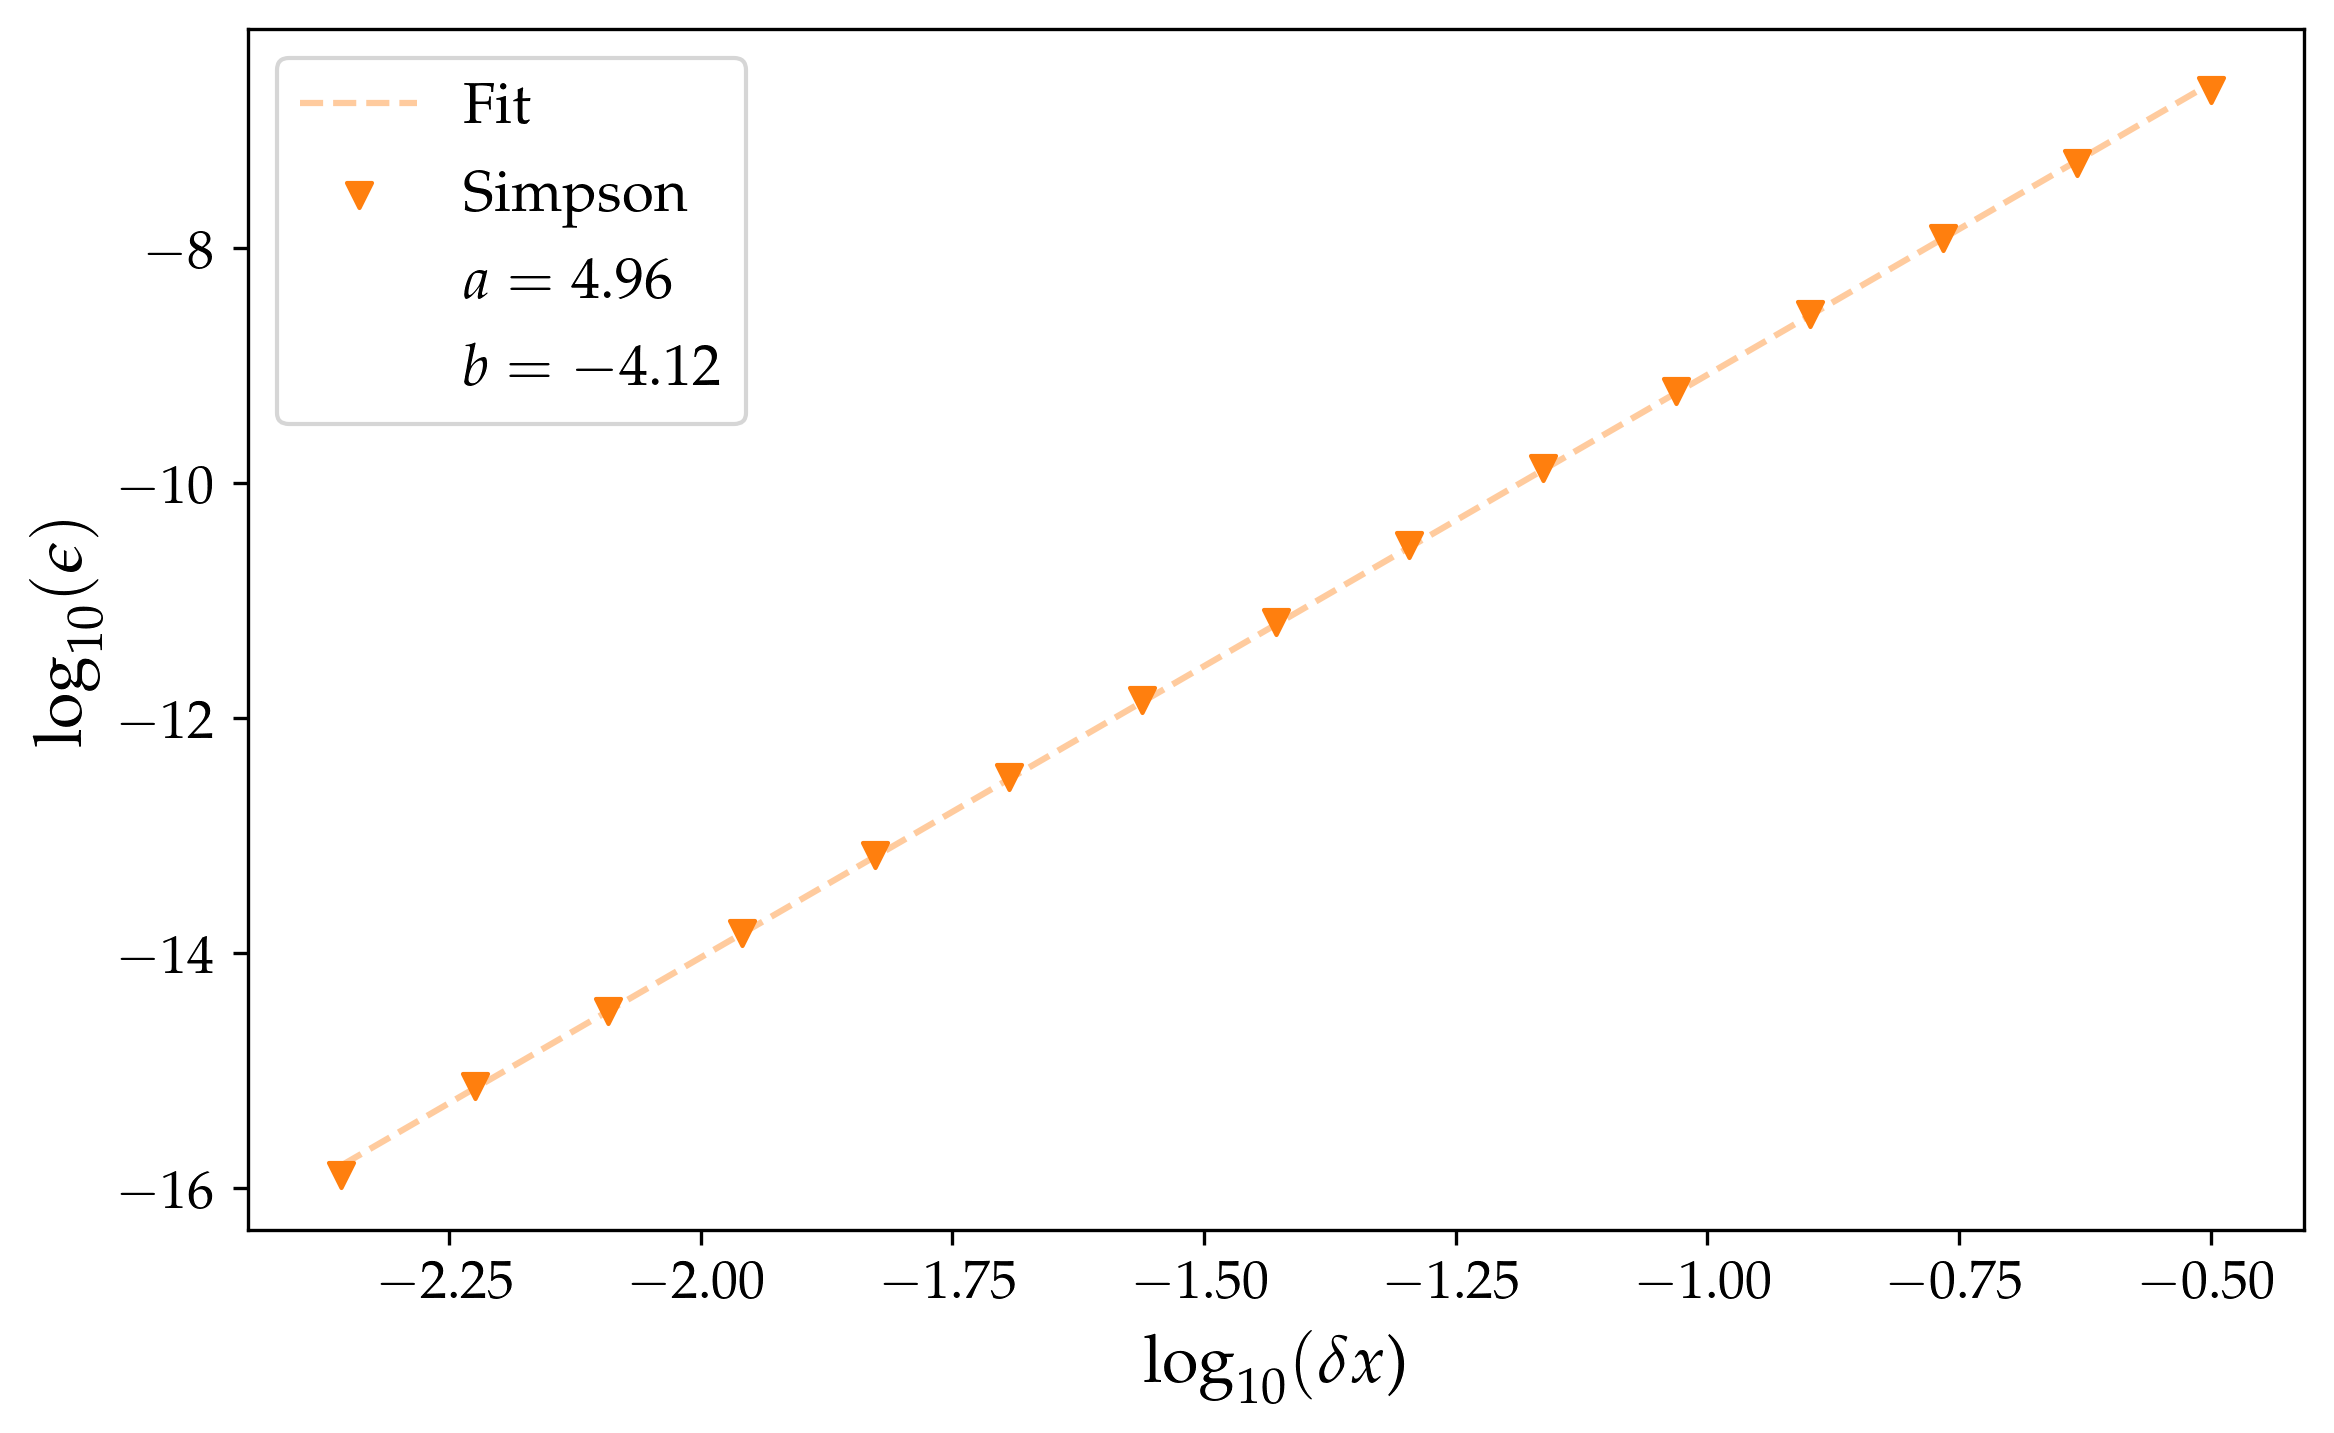

([np.float64(4.956631226616602), np.float64(-4.1236866544808235)],
 array([[0.20295858, 0.28994083],
        [0.28994083, 0.48086785]]),
 np.float64(0.013210896234469468),
 np.float64(1.0))

In [98]:
i = 1
cut = 35
dx, eps_dx = (dx_arr[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), 
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots\Fit_LocSimp')

# **Let's find an approximate value for $x_{max}$**

$$
I(x_{max}) = \int_0 ^{x_{max}} \frac{x^3}{e^x - 1} dx
$$

b = 43.63


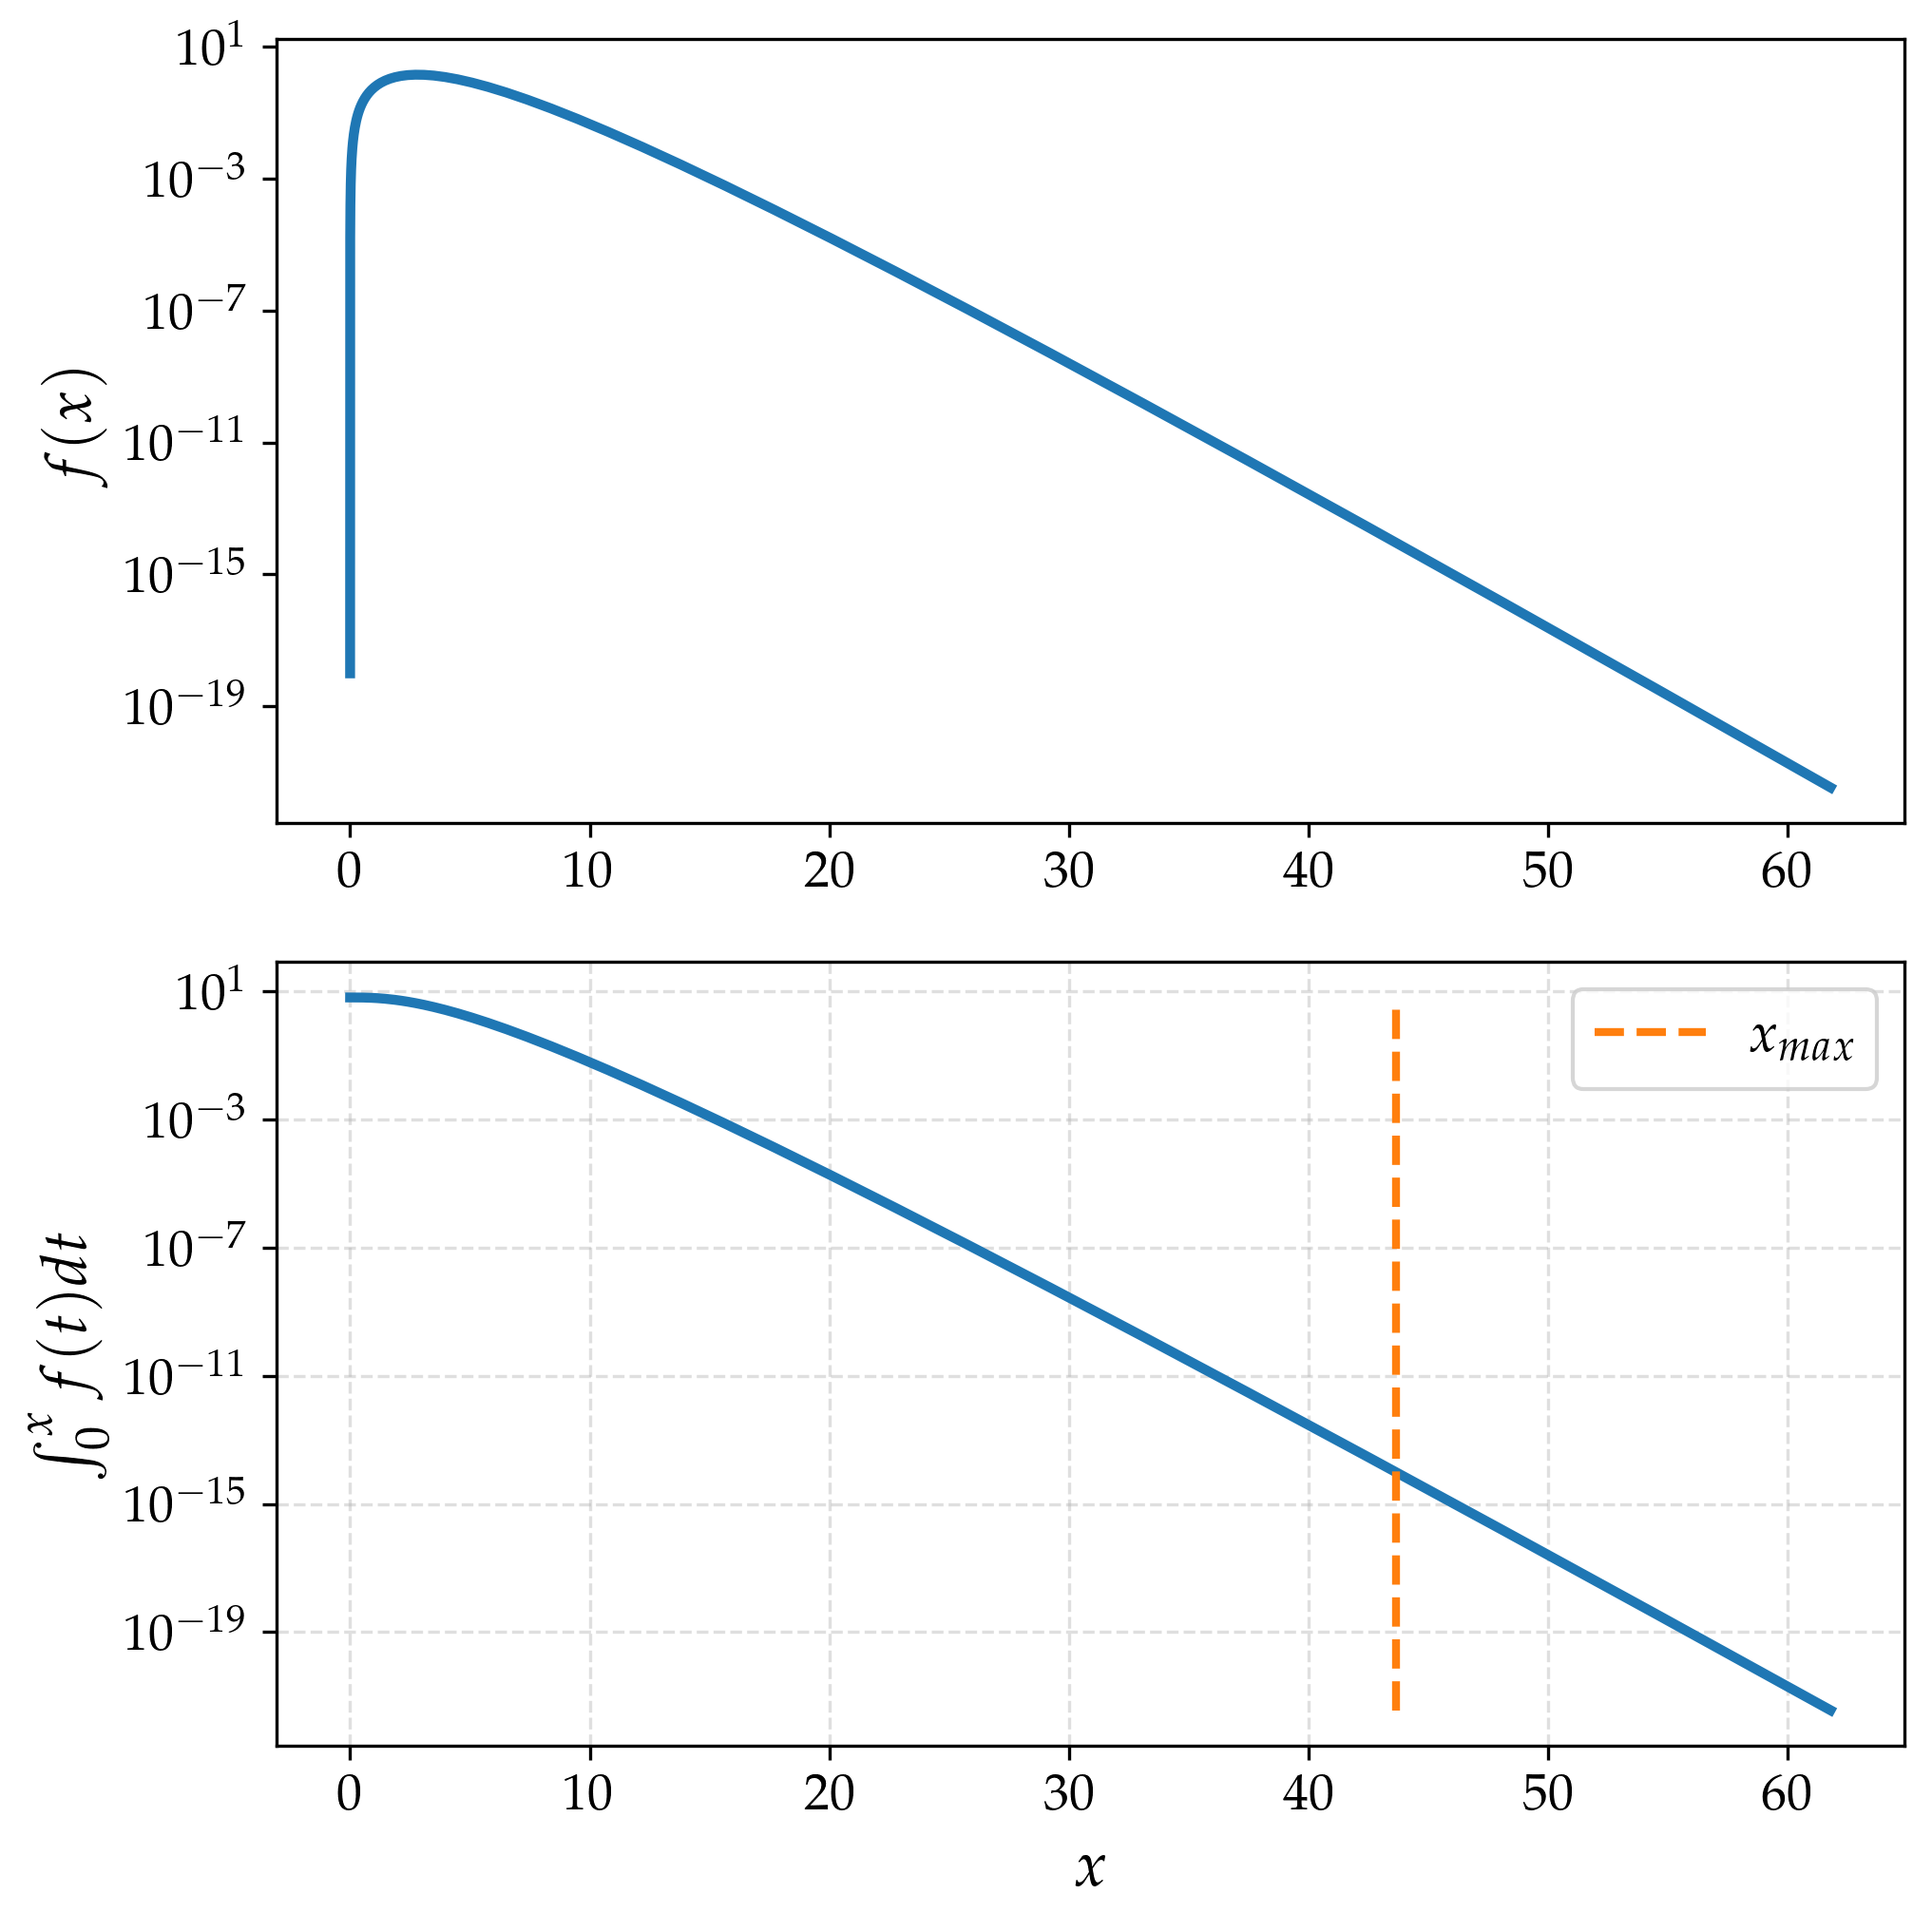

In [99]:
from lib_equations import bisec

# Params
a = 1e-9
max_samp = 70
dx_ = 1e-3
eps = 1e-14

func = lambda x: x**3 / (np.exp(x) - 1)
I_s = lambda x: Simpson(func, a, x, dx_)

zero_f = lambda x: np.log(x**3 + 3*x**2 + 6*x + 6) - (x + np.log(eps))
x_max = bisec(zero_f, 20, 50, tol=eps)

xcoo = np.logspace(np.log10(a), np.log10(max_samp), 200, endpoint=False)

f_x = func(xcoo)
int_s = [Simpson(func, x, max_samp, dx_) for x in xcoo]

print(f'b = {x_max:.2f}')


fig, axes = plt.subplots(2,1, figsize=(7, 7))
ax0, ax1 = axes.flatten()

ax0.plot(xcoo, f_x, lw=2.5)
ax1.plot(xcoo, int_s, lw=2.5)

ax1.set_xlabel(r'$x$')
ax0.set_ylabel(r'$f(x)$')
ax1.set_ylabel(r'$\int_0^{x} f(t) dt$')
ax1.vlines(x_max, min(int_s), max(int_s), ls='--', color='C1', label=r'$x_{max}$', lw=2)
ax1.grid(alpha=0.4, ls='--')
ax0.set_ylabel(r'$f(x)$')
ax0.set_yscale('log')
ax1.set_yscale('log')
ax1.legend()

plt.tight_layout()
plt.show()


In [100]:
b = x_max
b *= 1.1        # 10% confidence excess

res_t = trapezoidal(func, a, b, dx_)
res_s = Simpson(func, a, b, dx_)
true  = np.pi**4 / 15

# if x --> 0, f(x) --> x^2
# so the area before a can be evaluated analitically:
#   I_res = \int_(0, a) x^2 = a^3 / 3 

residual = a**3 / 3

# The numeric integral exclude the last part of the domain, 
leftover_t = trapezoidal(func, b, 2*b, dx_)
leftover_s = Simpson(func, b, 2*b, dx_)

diff_t = true - res_t  
diff_s = true - res_s 
# diff_t -= residual + leftover_t 
# diff_s -= residual + leftover_s 

diff_t, diff_s = abs(diff_t), abs(diff_s)

# Results
print(f'a = {a}')
print(f'b = {b}')
print('True =', true)
print(f'residual = {residual}')

print('\n\nTrapezoidal\'s Rule:')
print('\nI_t =', res_t)
print(f'leftover = {leftover_t}')
print('diff =',diff_t)

print('\n\nSimpson\'s Rule')
print('\nI_s =', res_s)
print(f'leftover = {leftover_s}')
print('diff =',diff_s)

print('\n\ndiff mths =', abs(res_s - res_t))

47996
47996
a = 1e-09
b = 47.99646397746432
True = 6.493939402266828
residual = 3.333333333333334e-28


Trapezoidal's Rule:

I_t = 6.493939402266825
leftover = 1.684397344412509e-16
diff = 2.6645352591003757e-15


Simpson's Rule

I_s = 6.493939402266846
leftover = 1.6843972208700793e-16
diff = 1.7763568394002505e-14


diff mths = 2.042810365310288e-14


# **Comparison, knowing $x_{max}$**

436331
397191
361562
329130
299606
272731
248266
225996
205724
187270
170472
155180
141260
128589
117054
106554
96996
88295
80375
73165
66602
60628
55189
50239
45732
41630
37895
34496
31402
28585
26021
23687
21562
19628
17867
16264
14805
13477
12268
11168
10166
9254
8424
7668
6980
6354
5784
5265
4793
4363


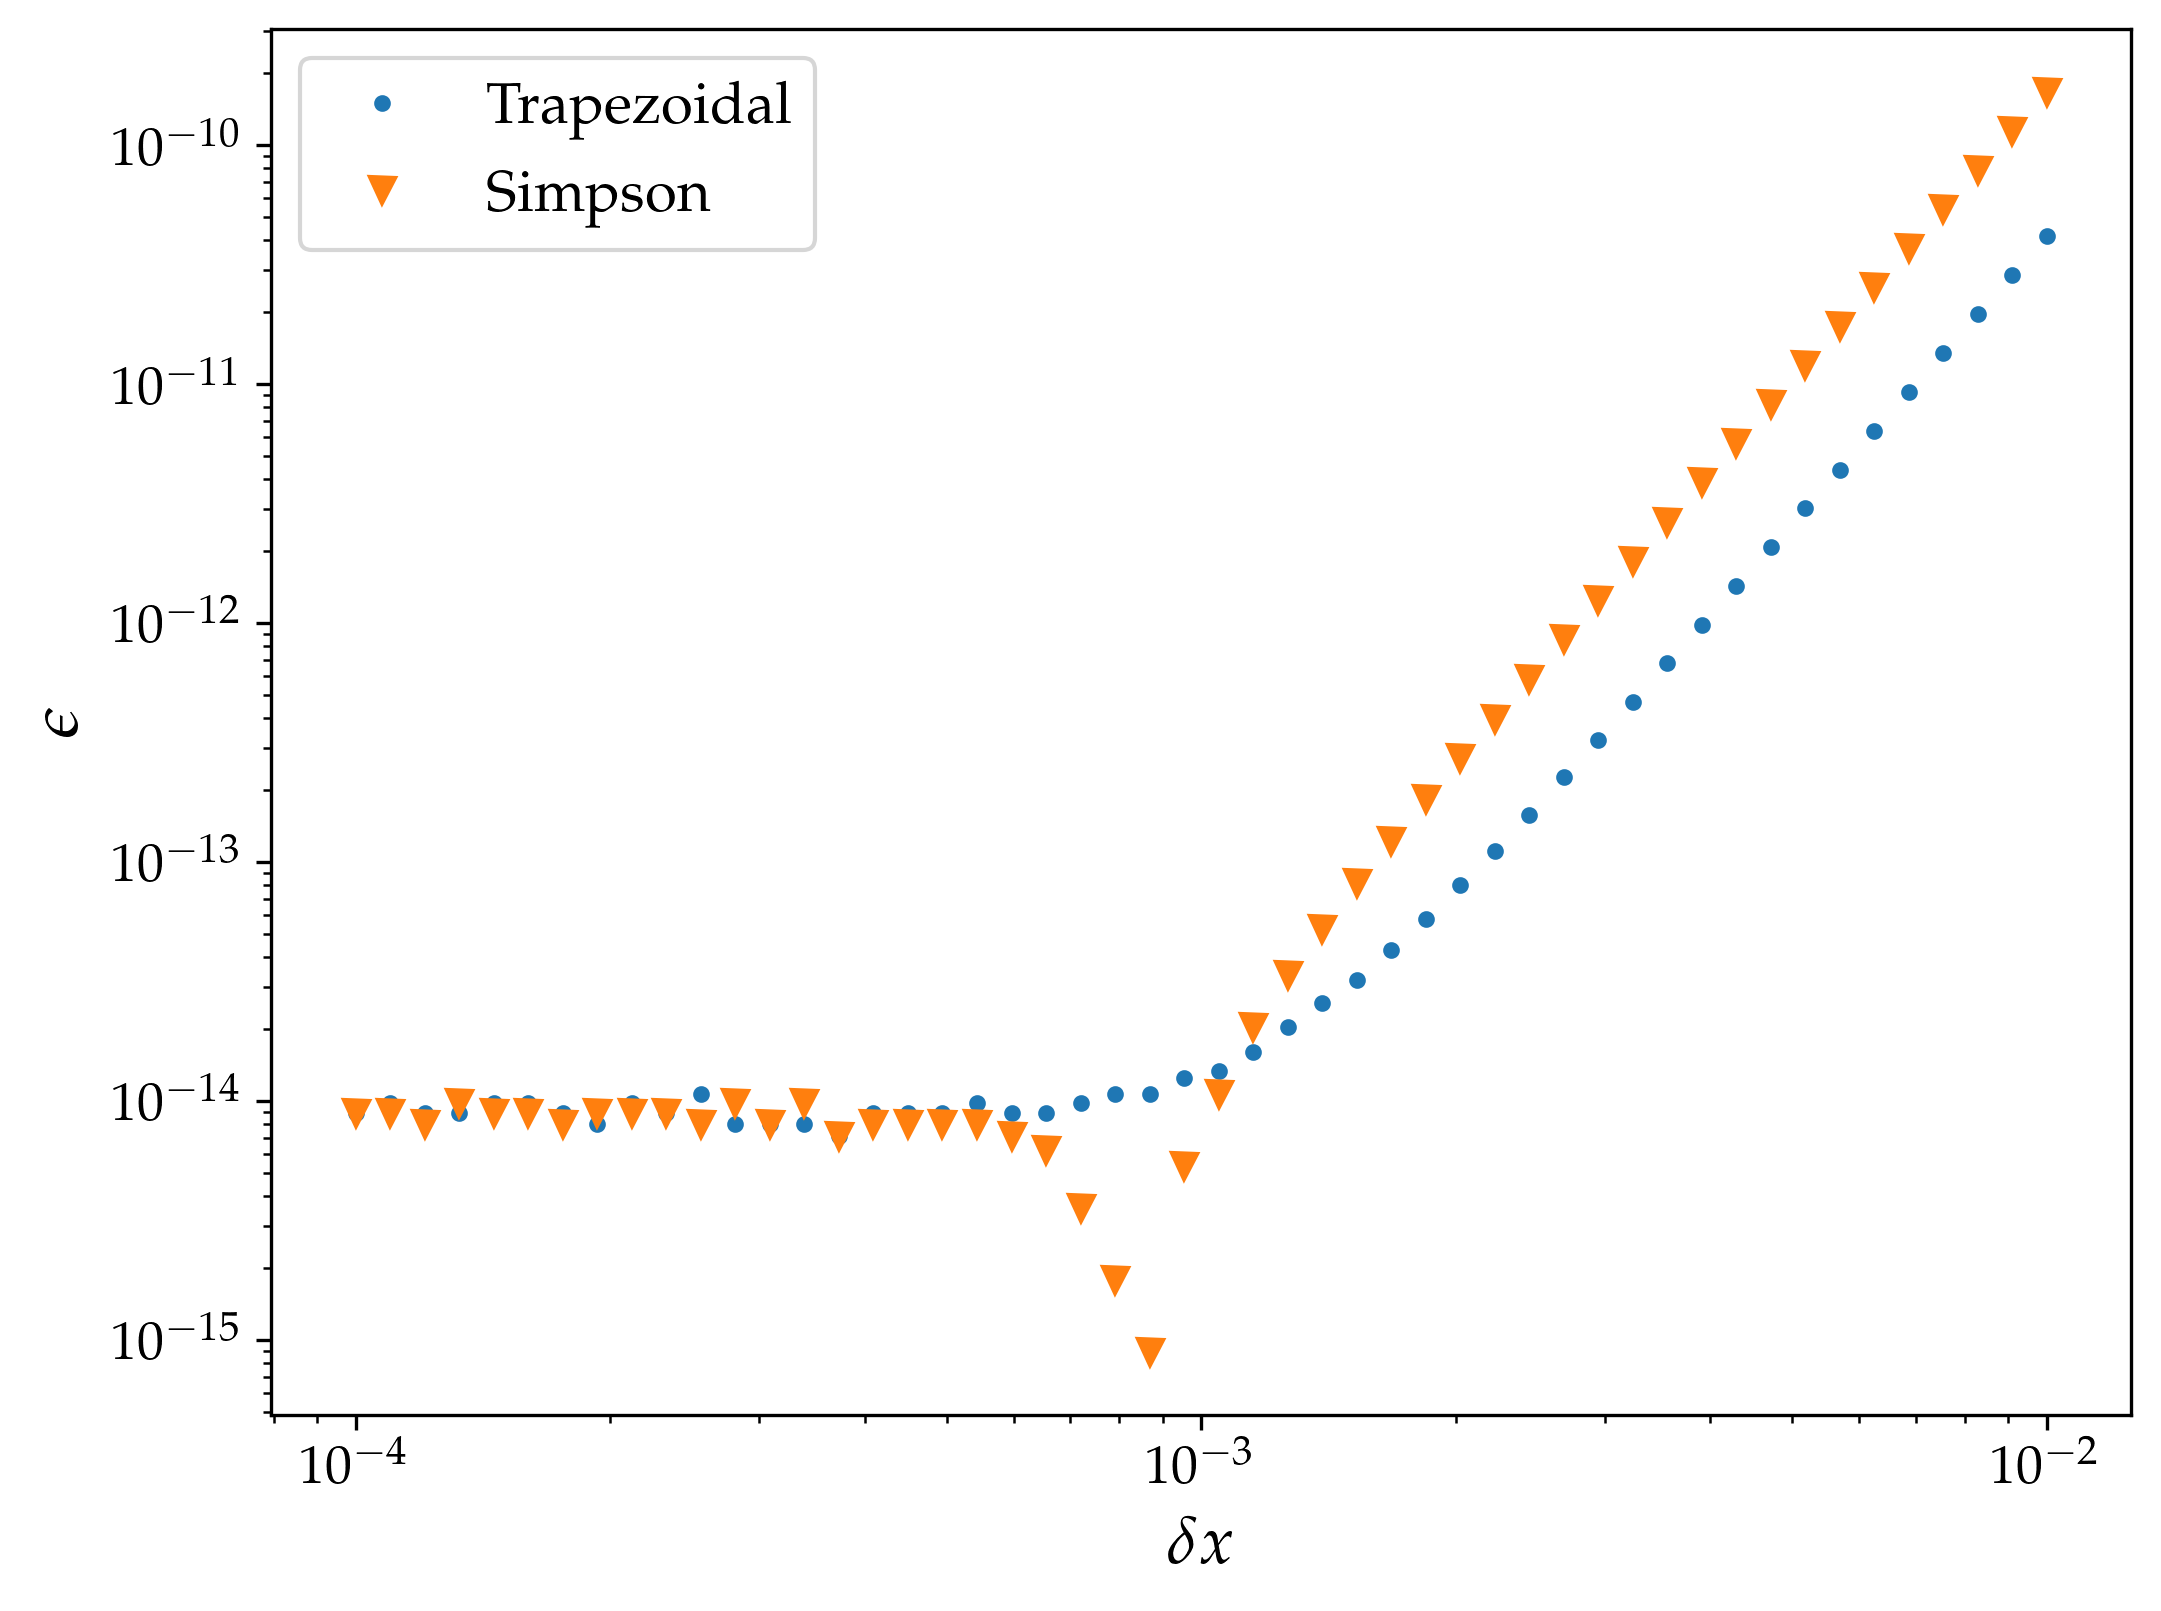

In [101]:
# Params
a = 1e-9
b = x_max
true  = np.pi**4 / 15

dx_span = np.logspace(-4, -2, 50)
eps = 1e-14
error = [[], []]

for dx_ in dx_span:
    for i in range(2):
        gr_spec = [['Trapezoidal', '.', trapezoidal], 
                [ 'Simpson', 'v', Simpson]]
        
        f_int = gr_spec[i][2]
        err = np.abs(f_int(func, a, b, dx=dx_) - true)
        error[i].append(err)

for i in range(2):
    plt.loglog(dx_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.show()


## **Check slope of *Trapezoidal***

In [102]:
i = 0 
cut = 35
dx, eps_dx = (dx_span[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), np.eye(len(dx)), 1,
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), ErrTrue=False,)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## **Check slope of *Simpson***

dof = 13

a = 4.01e+00 +/- 1.464e+00
b = -1.77e+00 +/- 3.357e+00

Chi2 = 0.00
p-val = 1.00


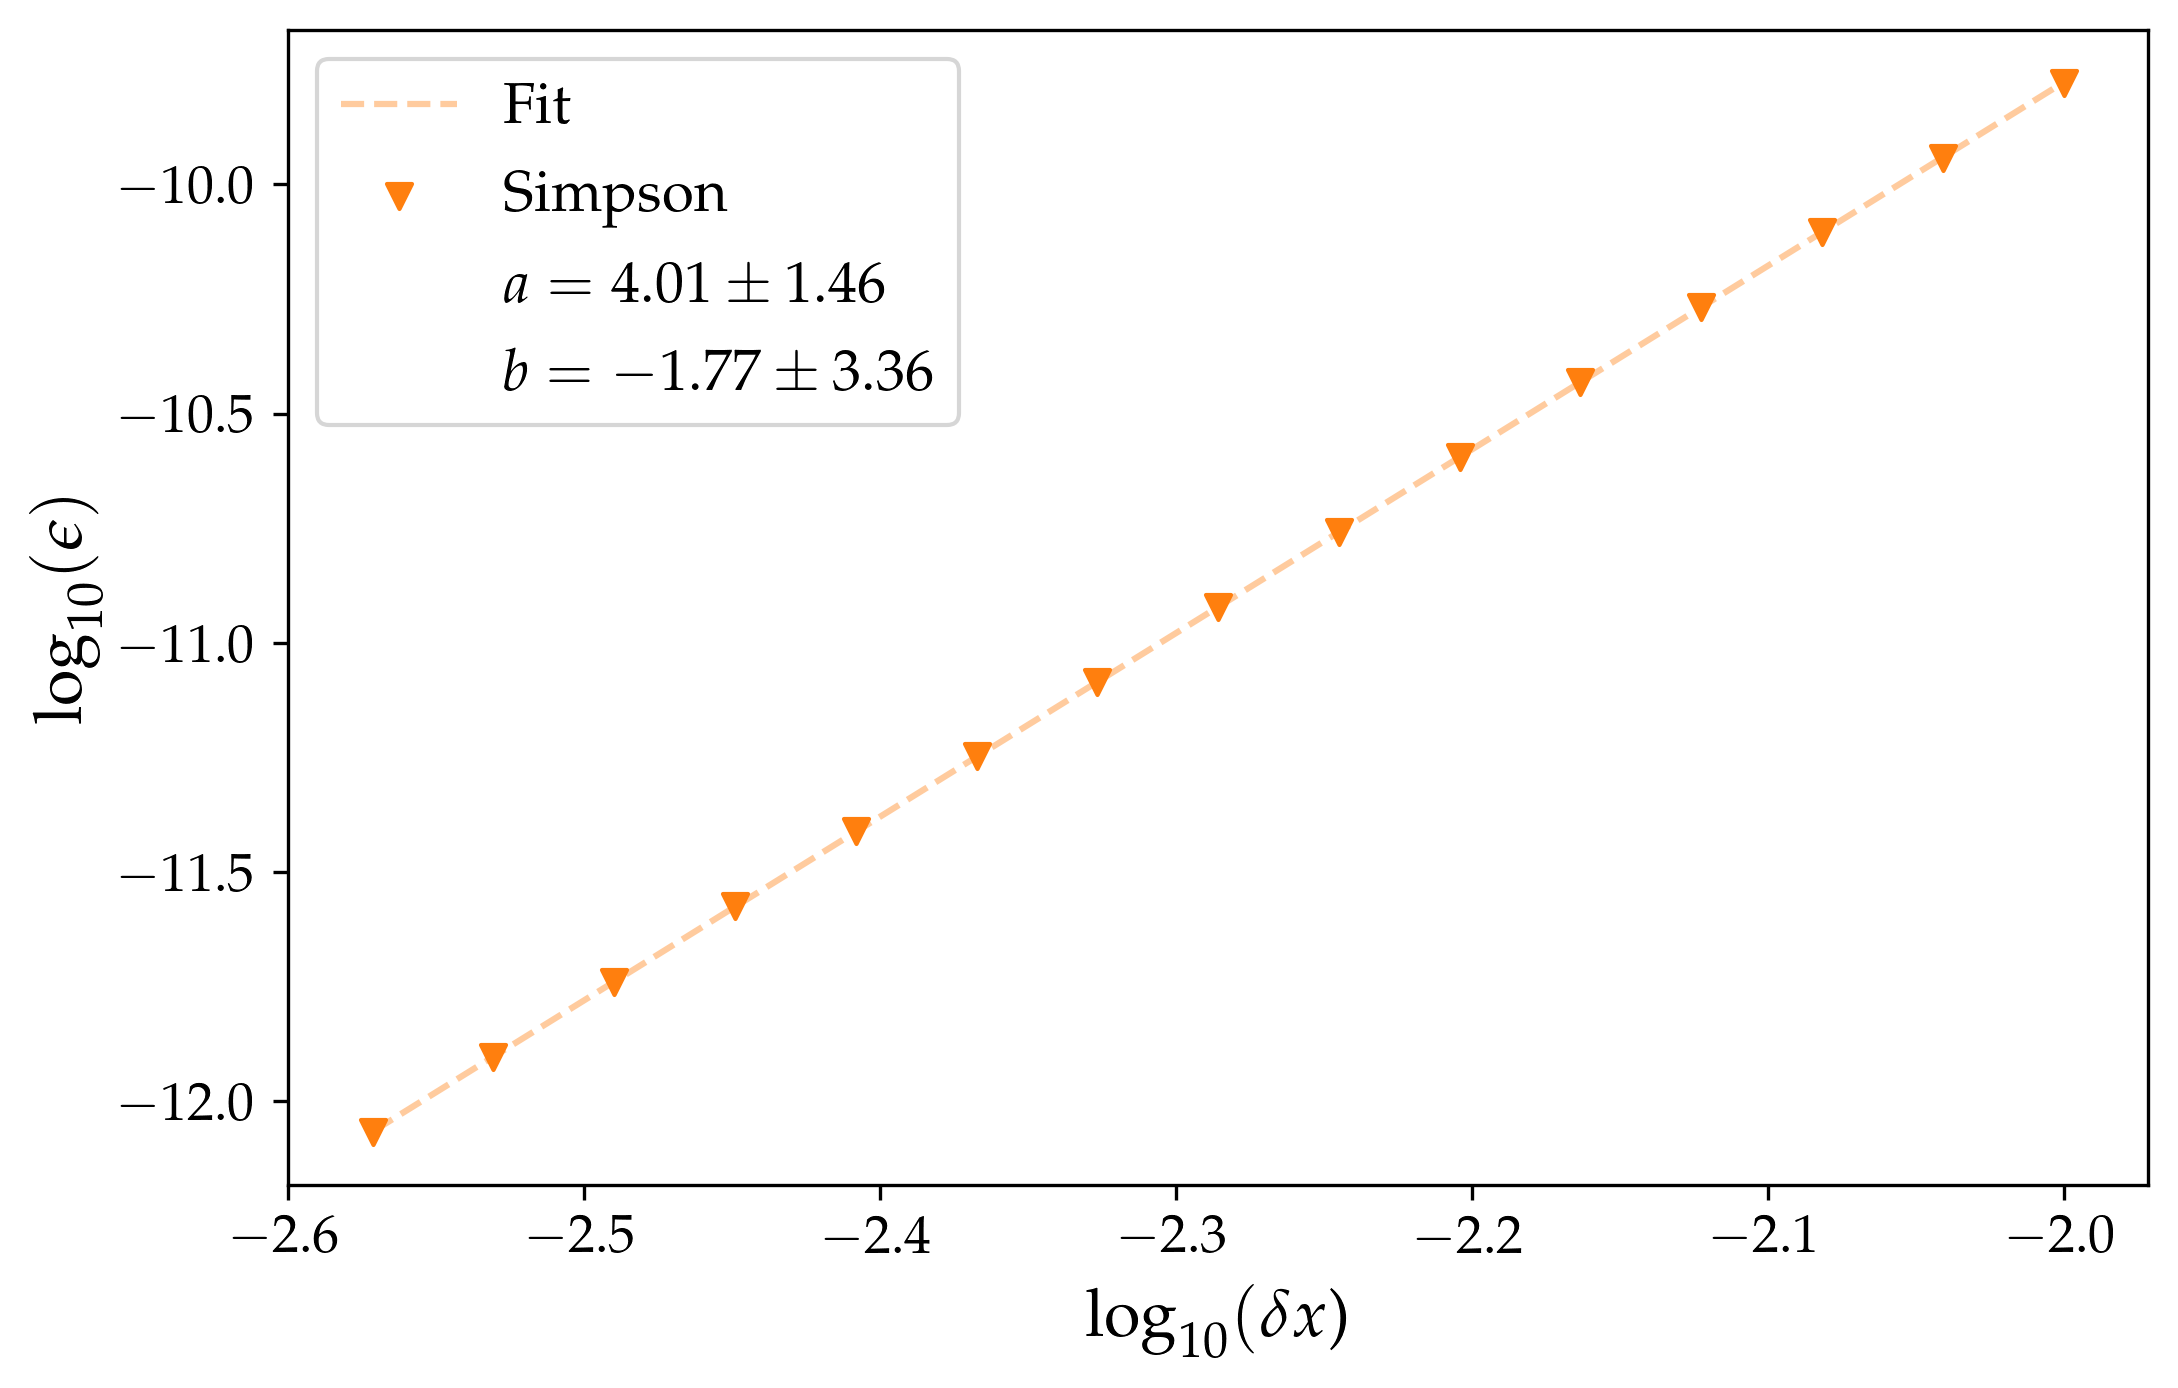

([np.float64(4.005989976619529), np.float64(-1.7654217004296098)],
 array([[ 2.14375   ,  4.9       ],
        [ 4.9       , 11.26666667]]),
 np.float64(9.66372874575633e-06),
 np.float64(1.0))

In [ ]:
i = 1
dx, eps_dx = (dx_span[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), np.eye(len(dx)), 1,
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), ErrTrue=False,)